In [2]:
# generate grids:
def grid_gen(xmin, xmax, mumin, mumax, nx, nmu, LOGSCALEX, DX1,X1LOW):
    # Generate polar coordinate arrays

    if(LOGSCALEX == 1):
        ii = np.linspace(0,nx-1,nx)
        x = np.exp(-X1LOW)*(np.exp(ii*DX1)-1.0)
    else:
        x = np.linspace(xmin,xmax,nx)
        
    mu = np.linspace(mumin,mumax,nmu)

    # Generate polar grid
    mu_grid, x_grid = np.meshgrid(mu, x)

    # Output
    return mu_grid, x_grid

def psi_gen(xgrid, mugrid, n_contours,aratio,dx,dmu,alpha):
        
    psi_grid = (1.0-mugrid*mugrid)/(xgrid/aratio+alpha)
    
    mu_levels = np.empty(n_contours)
    
    for i in range(n_contours):
        contour_mesh_value = (n_contours - i)/(n_contours+1.)/dmu
        mu_levels[i] = contour_mesh_value*dmu
        
    psi_levels = (1-mu_levels*mu_levels)/alpha

    return psi_grid, psi_levels

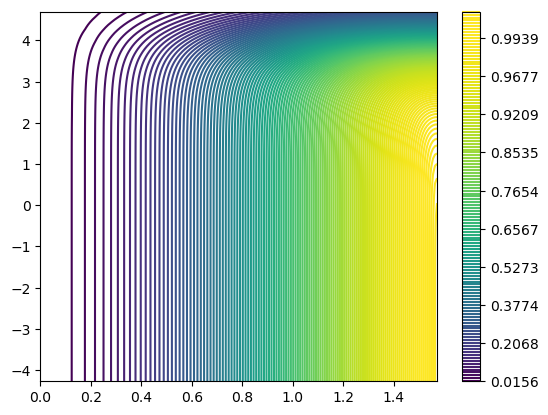

In [3]:
import numpy as np
from matplotlib import pyplot as plt

XMIN = 0
XMAX = 50000.0
MUMIN = 0.0
MUMAX = 1.0
X1LOW = 8.0
LOGSCALEX = 1
nr = 128
nth = 128
alpha_ratio = 1
n_contours = 127
x0 = 0.538
R_star = 1e4
aratio = R_star/x0

X1 = np.log(np.exp(X1LOW)*XMAX + 1.0)
DX1 = X1/(nr - 1.0)

if(LOGSCALEX == 1):
    dx = DX1
else:
    dx = (XMAX-XMIN)/(nr-1.0)
dmu = np.abs(MUMAX-MUMIN)/(nth-1.0)


mugrid, xgrid = grid_gen(XMIN,XMAX,MUMIN,MUMAX,nr,nth,LOGSCALEX,DX1,X1LOW)
psi_grid, psi_levels = psi_gen(xgrid, mugrid, n_contours,aratio,dx,dmu, alpha_ratio)

fig,ax = plt.subplots()
cb=ax.contour(np.arccos(mugrid[1:,:]),np.log10(xgrid[1:,:]),psi_grid[1:,:],levels=psi_levels)
fig.colorbar(cb)
plt.show()


In [5]:
from contourpy import contour_generator

def gen_contour_array(xgrid, mugrid, psi_grid, psi_levels):

    cont_gen = contour_generator(mugrid, xgrid, psi_grid, quad_as_tri=True)
    lines_arr_0 = np.array(cont_gen.lines(psi_levels[0]))[0]
    contour_array = np.hstack((lines_arr_0,np.reshape(np.zeros(len(lines_arr_0)),(-1,1))))

    for index in range(1,len(psi_levels)):
        # check if cont_gen.lines() returns an empty array:
        if(len(cont_gen.lines(psi_levels[index])[0]) == 0):
            continue
        else:
            lines = np.array(cont_gen.lines(psi_levels[index])[0])
            contour_array = np.append(contour_array, np.hstack((lines, np.reshape(index*np.ones(len(lines)), (-1,1)))), axis=0)

    # remove any contour coordinates below some limit xlim:
    # contour_array_output = contour_array[((contour_array[:,1] < 1.e-10))|(contour_array[:,1] > 1.e-3)]

    return contour_array

contour_array = gen_contour_array(xgrid,mugrid,psi_grid,psi_levels)

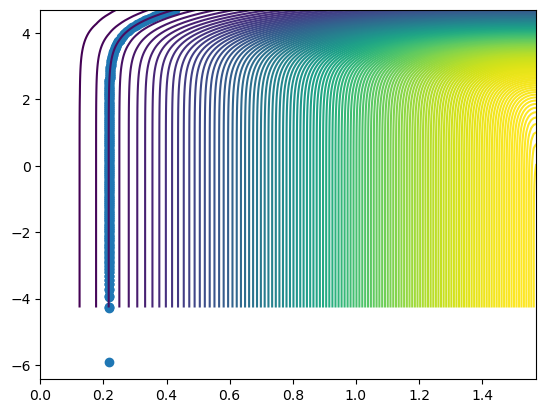

In [6]:
# Generate (r, theta) coordinates for the selected flux surface *psi* given by variable *index*.
index = 2
mucoords = contour_array[contour_array[:, 2] == index][:, 0]
xcoords = contour_array[contour_array[:, 2] == index][:, 1]
fig,ax = plt.subplots()
ax.contour(np.arccos(mugrid[1:,:]),np.log10(xgrid[1:,:]),psi_grid[1:,:],levels=psi_levels)
ax.scatter(np.arccos(mucoords[1:]),np.log10(xcoords[1:]))
plt.show()

In [7]:
def gen_s(mucoords,xcoords,alpha_ratio,aratio):
    avg_x = 0.5*(xcoords[1:] + xcoords[:-1])
    avg_mu = 0.5*(mucoords[1:] + mucoords[:-1])
    dxs = xcoords[1:] - xcoords[:-1]
    dmus = (avg_x + alpha_ratio*aratio)/np.sqrt((1.0 - avg_mu*avg_mu))*(mucoords[1:] - mucoords[:-1])
    ds = np.sqrt(dxs*dxs + dmus*dmus)
    s = np.append(0, np.cumsum(ds))
    return s 
    
def interpolate_function(data, mu, x, dmu, dx, LOGSCALEX, X1LOW):

    # Calc Nx, Nmu:
    nx = data.shape[0]
    nmu = data.shape[1]

    # Find base point, and distance of (mu,x) from the base point
    if(LOGSCALEX == 1):
        x1 = np.log(x + np.exp(-X1LOW)) + X1LOW
    else:
        x1 = x

    if((np.abs(x1/dx - np.rint(x1/dx)) > 1e-10) & (np.abs(x1/dx - np.rint(x1/dx)) < 1e-4)):
        ix = int(np.rint(x1/dx))
        xs=0.0
    else:
        ix = int(np.floor(x1/dx))
        xs = x1/dx - ix

    imu = int(np.floor(mu/dmu))
    mus = mu/dmu - imu

    if((ix < nx - 1) & (imu < nmu - 1)):
        data0 = data[ix, imu]
        data1 = data[ix, imu+1]
        data2 = data[ix+1, imu]
        data3 = data[ix+1, imu+1]
        
    if((ix == nx - 1) & (imu < nmu - 1)):
        data0 = data[ix, imu]
        data1 = data[ix, imu+1]
        data2 = 0
        data3 = 0

    if((imu == nmu - 1) & (ix < nx - 1)):
        data0 = data[ix, imu]
        data1 = 0
        data2 = data[ix+1, imu]
        data3 = 0

    if((imu == nmu - 1) & (ix == nx - 1)):
        data0 = data[ix, imu]
        data1 = data[ix, imu]
        data2 = data[ix, imu]
        data3 = data[ix, imu]

    interpolant = xs*mus*data3 + (1-mus)*xs*data2 + mus*(1-xs)*data1 + (1-xs)*(1-mus)*data0

    return interpolant

In [8]:
s = gen_s(mucoords, xcoords,alpha_ratio,aratio)
gradx_grid, gradmu_grid = np.gradient(psi_grid,xgrid[:,0],mugrid[0,:])
gradx = np.array([interpolate_function(gradx_grid, mucoords[i], xcoords[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s))])
gradmu = np.array([interpolate_function(gradmu_grid, mucoords[i], xcoords[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s))])

grad_psi_interp = np.array([np.sqrt(gradx[i]*gradx[i] + (1.0 - mucoords[i]*mucoords[i])/(xcoords[i] + alpha_ratio*aratio)/(xcoords[i] + alpha_ratio*aratio)*gradmu[i]*gradmu[i]) for i in range(len(s))])


In [9]:
def integrand_function(x, mu, grad_psi_vals, aratio, density,alpha_ratio):
    integrand = 2.0*np.pi*np.sqrt(1.0 - mu*mu)*(x + alpha_ratio*aratio)*density/(np.abs(grad_psi_vals))
    return integrand

In [10]:
from scipy import integrate
density_interp = 1.0
integrand_vals = integrand_function(xcoords, mucoords, grad_psi_interp, aratio, density_interp,alpha_ratio)
delta_mass_i = x0**3*integrate.simpson(integrand_vals, x=s)*(psi_levels[index+1] - psi_levels[index])
print(f"delta M_i = {delta_mass_i:0.6e}")

delta M_i = 2.367226e+12


In [11]:
# analytic method:
def mass_analytic(density,R_star,psi):
    chi = (1 - psi)**1.5
    xi = 8 + 12*psi+15*psi**2
    return -4*np.pi*density*R_star**3/105*(chi * xi)/psi**3

print(psi_levels[index],psi_levels[index+1])

delta_M_analytic = mass_analytic(density_interp, R_star, psi_levels[index+ 1]) - mass_analytic(density_interp, R_star, psi_levels[index])
print(f"delta M_i analytic = {delta_M_analytic:0.6e}")

0.04632568359375 0.0615234375
delta M_i analytic = 5.519013e+15


In [12]:
dmdpsi = np.zeros_like(psi_levels)
for index in range(len(psi_levels)):
    mucoords = contour_array[contour_array[:, 2] == index][:, 0]
    xcoords = contour_array[contour_array[:, 2] == index][:, 1]
    s = gen_s(mucoords, xcoords,alpha_ratio,aratio)
    gradx_grid, gradmu_grid = np.gradient(psi_grid,xgrid[:,0],mugrid[0,:])
    gradx = np.array([interpolate_function(gradx_grid, mucoords[i], xcoords[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s))])
    gradmu = np.array([interpolate_function(gradmu_grid, mucoords[i], xcoords[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s))])
    
    grad_psi_interp = np.array([np.sqrt(gradx[i]*gradx[i] + (1.0 - mucoords[i]*mucoords[i])/(xcoords[i] + alpha_ratio*aratio)/(xcoords[i] + alpha_ratio*aratio)*gradmu[i]*gradmu[i]) for i in range(len(s))])
    integrand_vals = integrand_function(xcoords, mucoords, grad_psi_interp, aratio, density_interp,alpha_ratio)
    dmdpsi[index] = x0**3*integrate.simpson(integrand_vals, x=s)

In [13]:
def chi(psi,alpha):
    return (1 - alpha*psi)**1.5
def xi(psi,alpha):
    return 8 + 12*alpha*psi + 15*alpha**2*psi**2
    
def dchi(psi,alpha):
    return -1.5*alpha*np.sqrt(1-alpha*psi)
def dxi(psi,alpha):
    return 12*alpha + 30*alpha**2*psi
psi_boundary = R_star/x0/(XMAX+aratio)
alpha_0 = x0*(XMAX+aratio)/R_star

print(psi_boundary)
dmdpsi_analytic = np.zeros_like(psi_levels)
dmdpsi_analytic[psi_levels > psi_boundary] = -4*np.pi*R_star**3/105*((psi_levels[psi_levels > psi_boundary]**3*(dchi(psi_levels[psi_levels > psi_boundary],1)*xi(psi_levels[psi_levels > psi_boundary],1) + chi(psi_levels[psi_levels > psi_boundary],1)*dxi(psi_levels[psi_levels > psi_boundary],1))) - 3*psi_levels[psi_levels > psi_boundary]**2 * chi(psi_levels[psi_levels > psi_boundary],1)*xi(psi_levels[psi_levels > psi_boundary],1))/psi_levels[psi_levels > psi_boundary]**6
dmdpsi_analytic[psi_levels < psi_boundary] = -4*np.pi*R_star**3/105*(((psi_levels[psi_levels < psi_boundary]**3*(dchi(psi_levels[psi_levels < psi_boundary],1)*xi(psi_levels[psi_levels < psi_boundary],1) + chi(psi_levels[psi_levels < psi_boundary],1)*dxi(psi_levels[psi_levels < psi_boundary],1))) - 3*psi_levels[psi_levels < psi_boundary]**2 * chi(psi_levels[psi_levels < psi_boundary],1)*xi(psi_levels[psi_levels < psi_boundary],1))/psi_levels[psi_levels < psi_boundary]**6 - ((psi_levels[psi_levels < psi_boundary]**3*(dchi(psi_levels[psi_levels < psi_boundary],alpha_0)*xi(psi_levels[psi_levels < psi_boundary],alpha_0) + chi(psi_levels[psi_levels < psi_boundary],alpha_0)*dxi(psi_levels[psi_levels < psi_boundary],alpha_0))) - 3*psi_levels[psi_levels < psi_boundary]**2 * chi(psi_levels[psi_levels < psi_boundary],alpha_0)*xi(psi_levels[psi_levels < psi_boundary],alpha_0))/psi_levels[psi_levels < psi_boundary]**6)
# dmdpsi_analytic[psi_levels<psi_boundary] = 


0.27100271002710025


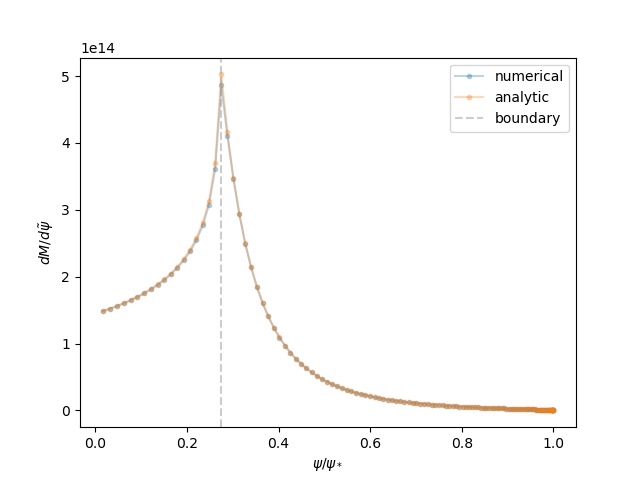

In [16]:
%matplotlib widget
fig,ax = plt.subplots()
ax.plot(psi_levels,dmdpsi,'.-',alpha = 0.3,label="numerical")
ax.plot(psi_levels,dmdpsi_analytic,'.-',alpha = 0.3,label="analytic")
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$dM/d\tilde{\psi}$")
ax.axvline(psi_levels[psi_levels>psi_boundary][0],color='grey',linestyle='dashed',alpha = 0.4,label="boundary")
ax.legend()
plt.show()

In [17]:
# calculate mass in fluxtube 6 in two different ways
from scipy.integrate import simpson as simpson
index = 6
dm_numerical_cumulative = np.array([simpson(dmdpsi[:k+1], x= psi_levels[:k+1]) for k in range(len(psi_levels))])
dm_numerical = dm_numerical_cumulative[index+1] - dm_numerical_cumulative[index]

dm_analytic_cumulative = np.array([simpson(dmdpsi_analytic[:k+1], x= psi_levels[:k+1]) for k in range(len(psi_levels))])
dm_analytic = dm_analytic_cumulative[index+1] - dm_analytic_cumulative[index]

dm_numerical_simple = np.array([simpson(dmdpsi[k:k+2],x=psi_levels[k:k+2]) for k in range(len(psi_levels))])

print(f"numerical: {dm_numerical:0.5e} \nanalytic: {dm_analytic:0.5e}\npct diff: {(dm_analytic - dm_numerical)/dm_analytic*100:0.4f}%")
print(f"numerical simple: {dm_numerical_simple[index]:0.5e}\npct diff: {(dm_analytic - dm_numerical_simple[index])/dm_analytic*100:0.4f}%")

numerical: 2.61647e+12 
analytic: 2.62618e+12
pct diff: 0.3700%
numerical simple: 2.61720e+12
pct diff: 0.3420%


also calc $dm = \int_\mathcal{C} \frac{ds \rho_0r \sin \theta}{|\nabla\psi|}\Delta \psi$ to compare

In [18]:
mucoords = contour_array[contour_array[:, 2] == index][:, 0]
xcoords = contour_array[contour_array[:, 2] == index][:, 1]
s = gen_s(mucoords, xcoords,alpha_ratio,aratio)
gradx_grid, gradmu_grid = np.gradient(psi_grid,xgrid[:,0],mugrid[0,:])
gradx = np.array([interpolate_function(gradx_grid, mucoords[i], xcoords[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s))])
gradmu = np.array([interpolate_function(gradmu_grid, mucoords[i], xcoords[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s))])

grad_psi_interp = np.array([np.sqrt(gradx[i]*gradx[i] + (1.0 - mucoords[i]*mucoords[i])/(xcoords[i] + alpha_ratio*aratio)/(xcoords[i] + alpha_ratio*aratio)*gradmu[i]*gradmu[i]) for i in range(len(s))])
integrand_vals = integrand_function(xcoords, mucoords, grad_psi_interp, aratio, density_interp,alpha_ratio)
dm_numerical_2 = x0**3*integrate.simpson(integrand_vals, x=s)*(psi_levels[index+1] - psi_levels[index])
print(f"numerical 2: {dm_numerical_2:0.5e}\npct diff: {(dm_analytic - dm_numerical_2)/dm_analytic*100:0.4f}%")

                                                          

numerical 2: 2.57319e+12
pct diff: 2.0178%


So doing it this way is not very accurate. Instead do it cumulatively.

In [19]:
vol_denom_b = grad_psi_interp
vol_integrand_b = (xcoords + aratio)*np.sqrt(1 - mucoords**2)/vol_denom_b

dvol_dpsi = np.array([2*np.pi*x0**3*simpson(vol_integrand_b[k:k+2], x=s[k:k+2]) for k in range(len(s))])
dvol_dpsi_2 = simpson(2*np.pi*x0**3*vol_integrand_b,x=s)
print(f"{np.sum(dvol_dpsi):0.5e}\n{dvol_dpsi_2:0.5e}\n{(np.sum(dvol_dpsi) - dvol_dpsi_2)/np.sum(dvol_dpsi)*100:0.5f}%")


1.74972e+14
1.74934e+14
0.02142%


In [20]:
# total volume in index i flux tube:
dvoldpsi = np.zeros_like(psi_levels)
for i in range(len(psi_levels)):
    mucoords = contour_array[contour_array[:, 2] == i][:, 0]
    xcoords = contour_array[contour_array[:, 2] == i][:, 1]
    s = gen_s(mucoords, xcoords,alpha_ratio,aratio)
    gradx_grid, gradmu_grid = np.gradient(psi_grid,xgrid[:,0],mugrid[0,:])
    gradx = np.array([interpolate_function(gradx_grid, mucoords[j], xcoords[j], dmu, dx, LOGSCALEX, X1LOW) for j in range(len(s))])
    gradmu = np.array([interpolate_function(gradmu_grid, mucoords[j], xcoords[j], dmu, dx, LOGSCALEX, X1LOW) for j in range(len(s))])
    
    grad_psi_interp = np.array([np.sqrt(gradx[j]*gradx[j] + (1.0 - mucoords[j]*mucoords[j])/(xcoords[j] + alpha_ratio*aratio)/(xcoords[j] + alpha_ratio*aratio)*gradmu[j]*gradmu[j]) for j in range(len(s))])
    integrand_vals = integrand_function(xcoords, mucoords, grad_psi_interp, aratio, 1,alpha_ratio)
    dvoldpsi[i] = x0**3*integrate.simpson(integrand_vals, x=s)

dvol = np.array([simpson(dvoldpsi[:k+1],x=psi_levels[:k+1]) for k in range(len(psi_levels))])

# dvol_index = dvol[index+1] - dvol[index]
# dvol_2 = np.array([simpson(dvoldpsi[k:k+2],x=psi_levels[k:k+2]) for k in range(len(psi_levels))])
# print(f"total volume in fluxtube index {index} = {dvol_index:0.5e}\ntotal volume in fluxtube index {index} = {dvol_2[index]:0.5e}")


    

What is happening in the code above? I am checking the different ways of calculating differential volume elements by integrating in different ways. In the first code block, I calculate the quantity __dV/dpsi__ by first creating an array of small volume elements $dV/d\psi_i = \int_{s_i}^{s_i+\Delta s} ds r\sin\theta\nabla\psi^{-1}$ and summing them up using `np.sum(dVdpsi_i)`, then comparing that to integrating along the whole length $dV/d\psi = \int ds r\sin\theta\nabla\psi^{-1}$. The result was that the values are very similar, within $0.02\%$.

Next, I compared actually calculating the volume __dV__ in fluxtube $i$ by integrating $dV/d\psi$ in two different ways. The first way, I generate an array `dvol` of cumulative values $dV = \int_0^{\psi_i}d\psi' \frac{dV}{d\psi'}$, and then calculate the mass between flux surfaces at `index = 6` by subtracting adjacent array values. The second way is to do it marginally from the beginning, $dV_i = \int_{\psi_i}^{\psi + d\psi}d\psi' \frac{dV}{d\psi'}$ and select the `index`-th entry directly. They are the same, effectively.

What does this tell us? We can calculate the volume element $dV_i$ at a point along flux surface $j$ by first integrating along the flux surface and then integrating over the increment $\psi + d\psi$:

In [21]:

mucoords = contour_array[contour_array[:, 2] == index][:, 0]
xcoords = contour_array[contour_array[:, 2] == index][:, 1]
s = gen_s(mucoords, xcoords,alpha_ratio,aratio)
gradx_grid, gradmu_grid = np.gradient(psi_grid,xgrid[:,0],mugrid[0,:])
gradx = np.array([interpolate_function(gradx_grid, mucoords[i], xcoords[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s))])
gradmu = np.array([interpolate_function(gradmu_grid, mucoords[i], xcoords[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s))])

grad_psi_interp = np.array([np.sqrt(gradx[i]*gradx[i] + (1.0 - mucoords[i]*mucoords[i])/(xcoords[i] + alpha_ratio*aratio)/(xcoords[i] + alpha_ratio*aratio)*gradmu[i]*gradmu[i]) for i in range(len(s))])
integrand_vals = integrand_function(xcoords, mucoords, grad_psi_interp, aratio, 1,alpha_ratio)
d_vol_s_dpsi = np.array([x0**3*integrate.simpson(integrand_vals[k:k+2],x=s[k:k+2]) for k in range(len(s))])

print(f"{np.sum(d_vol_s_dpsi):0.5e}")
# now integrate over psi

d_vol_s = simpson(d_vol_s_dpsi[index:index+2], x=psi_levels[index:index+2])

                         

1.74972e+14


### Calculating mass in fluxtube using adjacent points
Here I want to test using the previously written python function `gen_adjacent_point()` to generate a set of points on the adjacent flux surface, and then test calculating the mass in the flux tube by integrating over both $s$ and $\psi$. To do this, once the points are generated and the densities interpolated at the new points, the first integral is performed along each line
\begin{equation}
\left(\frac{dM}{d\psi}\right)_i = \int_\mathcal{C} ds r\sin\theta |\nabla\psi|^{-1} \rho
\end{equation}
Then the mass in the fluxtube is simply
\begin{equation}
\Delta M = \int_{\psi_i}^{\psi_i + d\psi} \left(\frac{dM}{d\psi'}\right)_i d\psi'
\end{equation}

In [22]:
from shapely.geometry import LineString
import shapely

def gen_adjacent_point(contour_array,mu_b,x_b, cont_number, point_number, gradx, gradmu, which_side, aratio, xmin, xmax, mumin, mumax, xg, mug, zg, zlevels, tag_string, plot_option):

    # extract contour coordinates of given flux line
    mucoords_b = contour_array[contour_array[:,2]==cont_number][:,0]
    xcoords_b = contour_array[contour_array[:,2]==cont_number][:,1]

    # extract coordinates of desired adjacent contour:
    mucoords_a = contour_array[contour_array[:,2]==cont_number+which_side][:,0]
    xcoords_a = contour_array[contour_array[:,2]==cont_number+which_side][:,1]

    # Construct normal curve to flux line to find intersection
    vector_mu_component = gradmu
    vector_x_component = gradx
    vector_magnitude = np.sqrt(vector_mu_component**2 + vector_x_component**2)
    vector_mu_vals = np.linspace(0, 1, 100)

    vector_gradient = vector_x_component / vector_mu_component
    vector_proj = vector_gradient*vector_mu_vals + (x_b - vector_gradient*mu_b)

    # Find where normal vector intersects adjacent contour curve using shapely package
    vector_linestring = np.c_[vector_mu_vals, vector_proj]
    ls1 = LineString(np.c_[mucoords_a, xcoords_a])
    ls2 = LineString(np.c_[vector_mu_vals, vector_proj])

    if(shapely.intersects(ls1,ls2)):
        # find intersection
        points = shapely.intersection(ls1,ls2)
        if(type(points).__name__=='Point'): # if the line intersects at a single point, the ls1 object will have a single entry
            mu_int, x_int = points.x, points.y
        elif(type(points).__name__=='MultiPoint'): # if the line intersects at two points, ls1 will be a multipoint object
            multipoint = points.geoms
            # find closest point in the case where the lines intersect multiple times. choose the point with the smallest distance between x values
            mp_delta_prev = 1e10 # pick a large number
            k = 0
            for i in range(len(multipoint)):
                mp_delta = np.abs(np.abs(multipoint[i].x - mu_b)) # calculate distance between i-th multipoint and point mu_b on original surface
                if(mp_delta < mp_delta_prev): # if the distance is closer, choose this point
                    k = i
                    mp_delta_prev = mp_delta
                else:
                    continue
            mu_int,x_int = multipoint[k].x, multipoint[k].y
    else:
        # return nearest value
        x_int = xcoords_a[np.abs(x_b - xcoords_a).argmin()]
        mu_int = mucoords_a[np.abs(x_b - xcoords_a).argmin()]
    # optional plotting
    plotting = plot_option
    # plotting = "on"
    if(((plotting == "on") | (plotting == 1)) & (point_number%10==0)):
        fig,ax = plt.subplots(figsize=(9,7)) 

        ax.contour(np.arccos(mug[1:,:]),np.log10(xg[1:,:]),zg[1:,:], levels = zlevels, alpha = 0.2)
        ax.scatter(np.arccos(mu_b),np.log10(x_b), c='green', label=r"$(x_j, \mu_j)$")
        ax.quiver(np.arccos(mu_b),np.log10(x_b), np.arccos(mu_b + vector_mu_component) - np.arccos(mu_b), np.log10((x_b + vector_x_component)/(x_b)),angles='xy',scale_units='xy',alpha=0.2,label='normal vector')
        ax.scatter(np.arccos(mucoords_a),np.log10(xcoords_a), alpha = 0.1, label=r"$\psi_{i-1}$")
        ax.scatter(np.arccos(mucoords_b),np.log10(xcoords_b), alpha = 0.1, label=r"$\psi_{i}$")
        ax.plot(np.arccos(vector_linestring[:,0]), np.log10(vector_linestring[:,1]), '.-r', alpha = 0.3)
        ax.scatter(np.arccos(mu_int),np.log10(x_int), c='red', label=r"$(x_j, \mu_j)^{(i-1)}$")

        plt.legend()
        ax.set(title=f"i={point_number}",xlabel=r"$\cos\theta$",ylabel=r"$\log_{10} \tilde{x}$")
        plt.show()

    return mu_int, x_int, vector_linestring, mucoords_a,xcoords_a


ModuleNotFoundError: No module named 'shapely'

/Users/ryanbrunet/mambaforge/lib/python3.10/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/ryanbrunet/mambaforge/lib/python3.10/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/var/folders/72/5_kw1gh53nn015l6nm1_9csw0000gn/T/ipykernel_76701/1193906014.py:59: RuntimeWarning: divide by zero encountered in log10
  ax.scatter(np.arccos(mucoords_a),np.log10(xcoords_a), alpha = 0.1, label=r"$\psi_{i-1}$")
/var/folders/72/5_kw1gh53nn015l6nm1_9csw0000gn/T/ipykernel_76701/1193906014.py:60: RuntimeWarning: divide by zero encountered in log10
  ax.scatter(np.arccos(mucoords_b),np.log10(xcoords_b), alpha = 0.1, label=r"$\psi_{i}$")


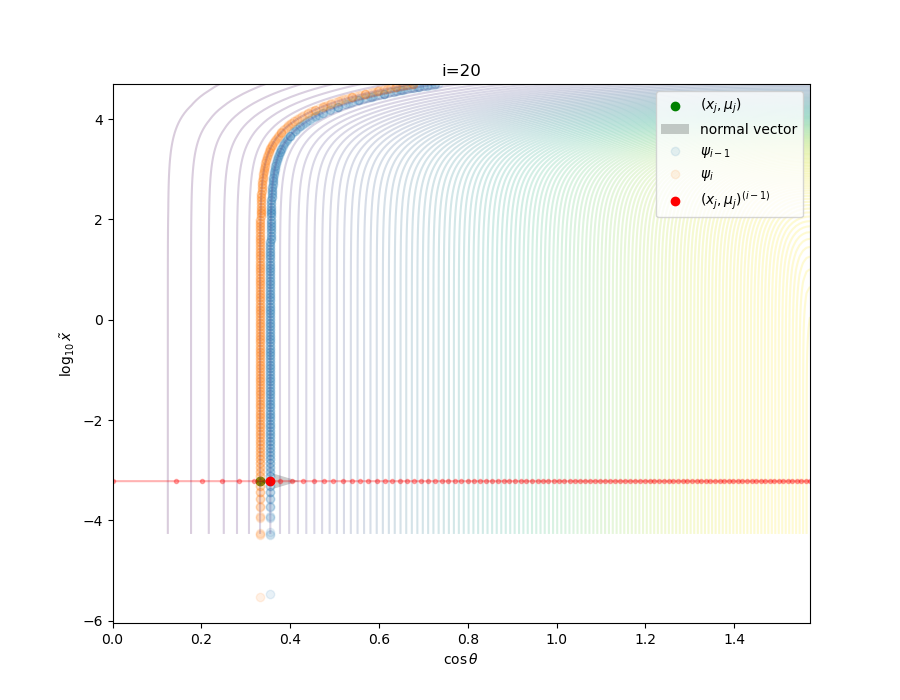

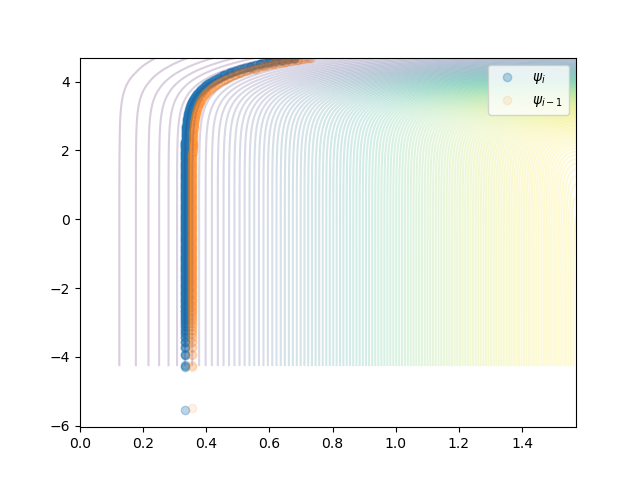

In [21]:

mu_int,x_int,_,mucoords_a,xcoords_a = gen_adjacent_point(contour_array, mucoords[20],xcoords[20], index,20,gradx[20],gradmu[20],1,aratio,XMIN,XMAX,MUMIN,MUMAX,xgrid,mugrid,psi_grid,psi_levels,1,1)

fig,ax = plt.subplots()
ax.contour(np.arccos(mugrid[1:,:]),np.log10(xgrid[1:,:]), psi_grid[1:,:],levels=psi_levels,alpha = 0.2)
ax.scatter(np.arccos(mucoords[1:]),np.log10(xcoords[1:]), alpha = 0.3, label=r"$\psi_{i}$")
ax.scatter(np.arccos(mucoords_a[1:]),np.log10(xcoords_a[1:]), alpha = 0.1, label=r"$\psi_{i-1}$")
ax.legend()
plt.show()



In [22]:
s_b = gen_s(mucoords, xcoords,alpha_ratio,aratio)
gradx_grid, gradmu_grid = np.gradient(psi_grid,xgrid[:,0],mugrid[0,:])
gradx = np.array([interpolate_function(gradx_grid, mucoords[i], xcoords[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s_b))])
gradmu = np.array([interpolate_function(gradmu_grid, mucoords[i], xcoords[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s_b))])
grad_psi_interp = np.array([np.sqrt(gradx[i]*gradx[i] + (1.0 - mucoords[i]*mucoords[i])/(xcoords[i] + alpha_ratio*aratio)/(xcoords[i] + alpha_ratio*aratio)*gradmu[i]*gradmu[i]) for i in range(len(s))])
integrand_vals = integrand_function(xcoords, mucoords, grad_psi_interp, aratio, density_interp,alpha_ratio)
dmdpsi_b = x0**3*integrate.simpson(integrand_vals, x=s_b)

s_a = gen_s(mucoords_a, xcoords_a,alpha_ratio,aratio)
gradx_a = np.array([interpolate_function(gradx_grid, mucoords_a[i], xcoords_a[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s_a))])
gradmu_a = np.array([interpolate_function(gradmu_grid, mucoords_a[i], xcoords_a[i], dmu, dx, LOGSCALEX, X1LOW) for i in range(len(s_a))])

grad_psi_interp_a = np.array([np.sqrt(gradx_a[i]*gradx_a[i] + (1.0 - mucoords_a[i]*mucoords_a[i])/(xcoords_a[i] + alpha_ratio*aratio)/(xcoords_a[i] + alpha_ratio*aratio)*gradmu_a[i]*gradmu_a[i]) for i in range(len(s_a))])
integrand_vals_a = integrand_function(xcoords_a, mucoords_a, grad_psi_interp_a, aratio, density_interp,alpha_ratio)
dmdpsi_a = x0**3*integrate.simpson(integrand_vals_a, x=s_a)

mass = simpson(np.array([dmdpsi_b,dmdpsi_a]), x=psi_levels[index:index+2])
print(index)
print(f"mass: {mass:0.5e}\nnumerical: {dm_analytic:0.5e}\npct diff: {(mass - dm_analytic)/dm_analytic*100}%")


6
mass: 2.61720e+12
numerical: 2.62618e+12
pct diff: -0.3419650178863962%


This appears to work well. So the next step is to calculate the mass of a single small element.

In [23]:
s_b = np.flip(s_b)
integrand_vals = np.flip(integrand_vals)
s_a = np.flip(s_a)
integrand_vals_a = np.flip(integrand_vals_a)

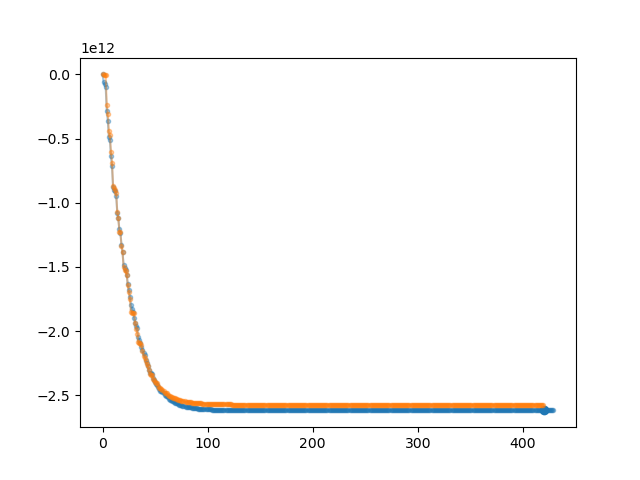

sum 2 = -2.57374e+12, mass = -2.61721e+12 1.66094%


In [24]:
mass_k = np.zeros_like(s_b)
alt_mass = np.zeros_like(s_b)

for k in range(len(s_b)+10):

    if(k < len(s_b)):
        dmdpsi_ik = x0**3*integrate.simpson(integrand_vals[k:k+2],x=s_b[k:k+2])
        dmdpsi_ak = x0**3*integrate.simpson(integrand_vals_a[k:k+2],x=s_a[k:k+2])
        mass_k[k] = simpson(np.array([dmdpsi_ik,dmdpsi_ak]), x = psi_levels[index:index+2])
        alt_mass[k] = dmdpsi_ik*(psi_levels[index+1] - psi_levels[index])
    else:
        j = len(s_b)-1
        dmdpsi_ik = x0**3*integrate.simpson(integrand_vals[j:k+2],x=s_b[j:k+2])
        dmdpsi_ak = x0**3*integrate.simpson(integrand_vals_a[j:k+2],x=s_a[j:k+2])
        mass_k[j] = simpson(np.array([dmdpsi_ik,dmdpsi_ak]), x = psi_levels[index:index+2])
        alt_mass[j] = dmdpsi_ik*(psi_levels[index+1] - psi_levels[index])


cumulative_mass_k = np.array([np.sum(mass_k[:k]) for k in range(len(s_b)+10)])
alt_cumulative_mass_k = np.array([np.sum(alt_mass[:k]) for k in range(len(s_b))])
dmdpsi_0 = x0**3 * integrate.simpson(integrand_vals[:k+10],x=s_b[:k+10])
dmdpsi_1 = x0**3 * integrate.simpson(integrand_vals_a[:k+10],x=s_a[:k+10])
mass = simpson(np.array([dmdpsi_0,dmdpsi_1]), x=psi_levels[index:index+2])

fig,ax = plt.subplots()
ax.plot(cumulative_mass_k,'.-',alpha = 0.4)
ax.plot(alt_cumulative_mass_k, '.-',alpha = 0.4)
# ax.plot(np.abs(cumulative_mass_k-alt_cumulative_mass_k)/cumulative_mass_k*100, '.-',alpha = 0.4)
ax.scatter(len(s_b),mass)
plt.show()
print(f"sum 2 = {np.sum(alt_mass):0.5e}, mass = {mass:0.5e} {(mass - np.sum(alt_mass))/mass*100:0.5f}%")

/var/folders/72/5_kw1gh53nn015l6nm1_9csw0000gn/T/ipykernel_76701/2452903301.py:14: RuntimeWarning: invalid value encountered in divide
  ax2.plot(np.abs(cumulative_mass_k_trunc-alt_cumulative_mass_k_trunc)/cumulative_mass_k_trunc*100, '.-',alpha = 0.4)


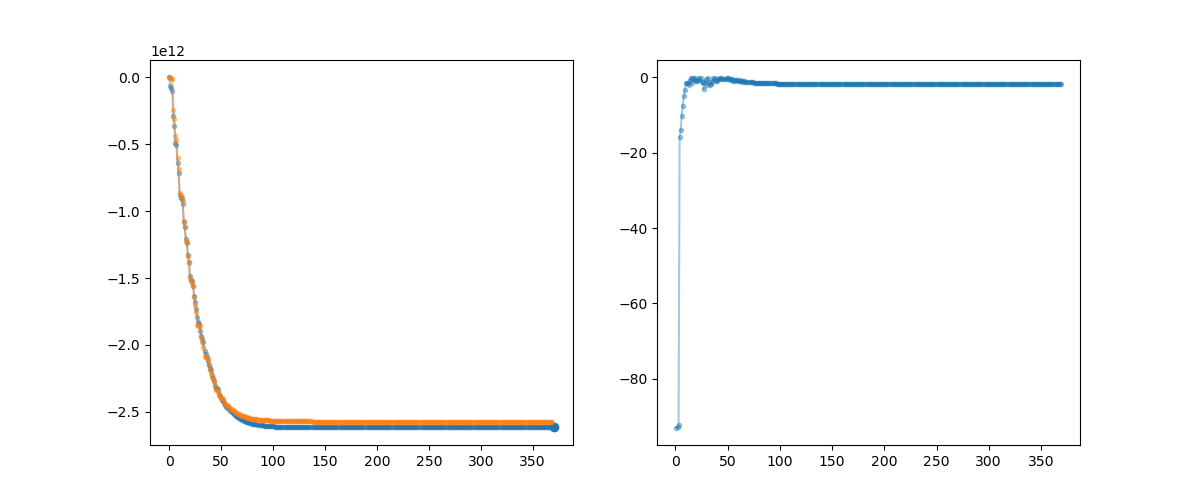

In [25]:
# check whether the integration works when stopping midway up the fluxtube
fluxtube_index_end = len(s_b) - 50
k = fluxtube_index_end
cumulative_mass_k_trunc = np.array([np.sum(mass_k[:k]) for k in range(fluxtube_index_end)])
alt_cumulative_mass_k_trunc = np.array([np.sum(alt_mass[:k]) for k in range((fluxtube_index_end))])
dmdpsi_0 = x0**3 * integrate.simpson(integrand_vals[:k],x=s_b[:k])
dmdpsi_1 = x0**3 * integrate.simpson(integrand_vals_a[:k],x=s_a[:k])
mass = simpson(np.array([dmdpsi_0,dmdpsi_1]), x=psi_levels[index:index+2])

fig,(ax,ax2) = plt.subplots(1,2,figsize=(12,5))
ax.plot(cumulative_mass_k_trunc,'.-',alpha = 0.4)
ax.plot(alt_cumulative_mass_k_trunc, '.-',alpha = 0.4)
ax.scatter(fluxtube_index_end,mass)
ax2.plot(np.abs(cumulative_mass_k_trunc-alt_cumulative_mass_k_trunc)/cumulative_mass_k_trunc*100, '.-',alpha = 0.4)
plt.show()
# print(f"sum 2 = {np.sum(alt_mass):0.5e}, mass = {mass:0.5e} {(mass - np.sum(alt_mass))/mass*100:0.5f}%")


6
420


/var/folders/72/5_kw1gh53nn015l6nm1_9csw0000gn/T/ipykernel_76701/1521654177.py:35: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.log10(s_b),np.cumsum(mass_elements),'.-',alpha=0.4,label="mass elements")


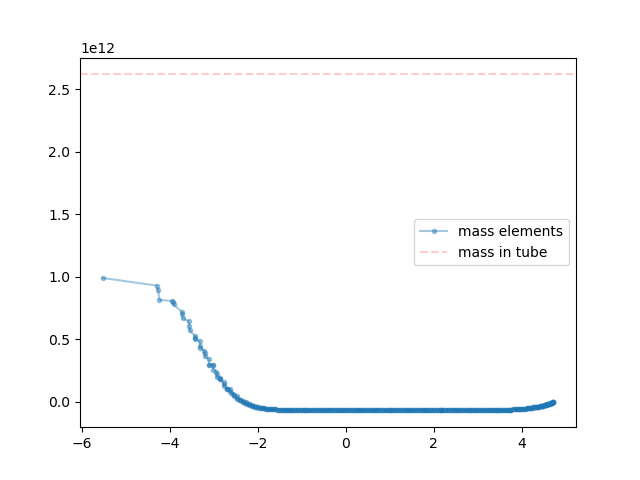

In [26]:
print(index)
mucoords_adj = np.copy(mucoords_a)
xcoords_adj = np.copy(xcoords_a)
density = np.copy(density_interp)*np.ones_like(psi_grid)
grad_psi_interp_b = np.copy(grad_psi_interp)

s_a = gen_s(mucoords_adj, xcoords_adj, alpha_ratio, aratio)
gradx_a = np.array([interpolate_function(gradx_grid, mucoords_adj[i],xcoords_adj[i],dmu,dx,LOGSCALEX,X1LOW) for i in range(len(s_a))])
gradmu_a = np.array([interpolate_function(gradmu_grid, mucoords_adj[i],xcoords_adj[i],dmu,dx,LOGSCALEX,X1LOW) for i in range(len(s_a))])
grad_psi_interp_a = np.sqrt(gradx_a**2 + (1.0 - mucoords_adj**2)/(xcoords_adj + alpha_ratio*aratio)/(xcoords_adj + alpha_ratio*aratio)*gradmu_a**2)

density_a = np.array([interpolate_function(density, mucoords_adj[i],xcoords_adj[i], dmu,dx, LOGSCALEX, X1LOW) for i in range(len(s_a))])
density_b = np.copy(density_interp)*np.ones_like(s_b)


vol_denom_a = grad_psi_interp_a
vol_denom_a[grad_psi_interp_a < 1.e-10] = np.max(grad_psi_interp_a)*1.e-3
vol_integrand_a = (xcoords_adj + aratio)*np.sqrt(1. - mucoords_adj**2)/(vol_denom_a)

vol_denom_b = grad_psi_interp_b
vol_denom_b[grad_psi_interp_b < 1.e-10] = np.max(grad_psi_interp_b)*1.e-3
vol_integrand_b = (xcoords + aratio)*np.sqrt(1. - mucoords**2)/(vol_denom_b)

dmdpsi_a = 2.*np.pi*x0**3*np.array([simpson(vol_integrand_a[k:k+2]*density_a[k:k+2], x=s_a[k:k+2]) for k in range(len(s_a))])
dmdpsi_b = 2.*np.pi*x0**3*np.array([simpson(vol_integrand_b[k:k+2]*density_b[k:k+2], x=s_b[k:k+2]) for k in range(len(s_b))])
# print(len(dmdpsi_a),len(dmdpsi_b))
# sys.exit()
min_len = np.minimum(len(s_a),len(s_b))
print(min_len)
mass_elements = np.array([simpson(np.array([dmdpsi_a[k],dmdpsi_b[k]]), x=psi_levels[index:index+2]) for k in range(min_len)])

mass_in_tube = simpson(dmdpsi[index:index+2], x=psi_levels[index:index+2])

fig,ax = plt.subplots()
ax.plot(np.log10(s_b),np.cumsum(mass_elements),'.-',alpha=0.4,label="mass elements")
ax.axhline(y = mass_in_tube, color='r',label="mass in tube",linestyle='--',alpha = 0.2)
ax.legend()
plt.show()

In [27]:
aaa = np.arange(0,20,2)
print(aaa)
interval_starts = np.array([2,6])
print(aaa[interval_starts-1])

[ 0  2  4  6  8 10 12 14 16 18]
[ 2 10]


In [33]:
a = 
np.sum(np.array([8.880e+21, 7.331e+21, 2.487e+21, 0.000e+00, 0.000e+00, 2.268e+21, 1.990e+21, 2.729e+21, 2.186e+21, 1.170e+21]))
b = np.sum(np.array([8.284e+21, 8.004e+21, 2.411e+21, 0.000e+00, 0.000e+00, 1.467e+21, 1.469e+21, 2.901e+21, 2.701e+21, 1.806e+21]))
print(a,b)

2.9041e+22 2.9042999999999997e+22


In [2]:
print(xgrid)

NameError: name 'xgrid' is not defined